# Agent Orchestration 

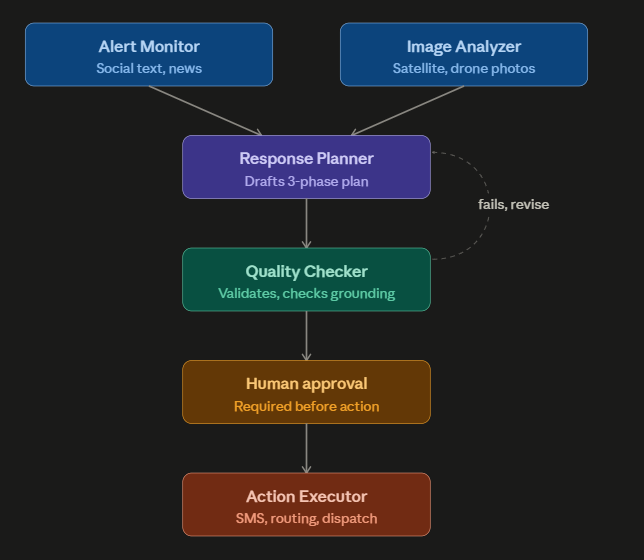

In [ ]:
from typing import TypedDict

class GenesisState(TypedDict):
    raw_input: str
    alert_classification: str
    image_findings: str
    response_plan: str
    quality_check_passed: bool
    retry_count: int # a new field, retry_count, is added on purpose — without it, a bad plan could loop forever between Response Planner and Quality Checker.
    

In [ ]:
def alert_monitor_node(state: GenesisState)->GenesisState:
    """This node monitors the alert and classifies it into one of the categories: 'flood', 'earthquake', 'fire', 'other'."""
    print("Alert Monitor running")
    state["alert_classification"] = f"classified:{state['raw_input']}"
    return state


def image_analyzer_node(state:GenesisState)-> GenesisState:
    """This node analyzes the image and provides findings."""
    print("Image Analyzer running")
    state["image_findings"] = "dummy { no image yet provided}"
    return state

def response_planner_node(state: GenesisState) -> GenesisState:
    print("Response Planner running...")
    state["response_plan"] = f"PLAN based on [{state['alert_classification']}] + [{state['image_findings']}]"
    return state 

def quality_checker_node(state: GenesisState) -> GenesisState:
    print("Quality Checker running...")
    state["retry_count"] += 1
    # dummy rule for now: fail once, then pass — just to prove the loop works
    state["quality_check_passed"] = state["retry_count"] >= 2
    return state


def route_after_quality_check(state: GenesisState) -> str:
    if state["quality_check_passed"]:
        return "action_executor"
    if state["retry_count"] >= 3:
        return "action_executor"  # safety valve: stop retrying, flag for human review instead
    return "response_planner"

# route_after_quality_check doesn't run any logic itself — it just looks at the state and returns the name of whichever node should run next. 
# That's the whole idea of a conditional edge: a plain Python function deciding the path.


def action_executor_node(state: GenesisState) -> GenesisState:
    print("Action Executor running (dummy — would need human approval here)")
    return state

In [15]:
from langgraph.graph import StateGraph , END

from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(GenesisState)
builder.add_node("alert_monitor", alert_monitor_node)
builder.add_node("image_analyzer", image_analyzer_node)
builder.add_node("response_planner", response_planner_node)
builder.add_node("quality_checker", quality_checker_node)
builder.add_node("action_executor", action_executor_node)

builder.set_entry_point("alert_monitor")
builder.add_edge("alert_monitor", "image_analyzer")
builder.add_edge("image_analyzer", "response_planner")
builder.add_edge("response_planner", "quality_checker")
builder.add_conditional_edges(
    "quality_checker",
    route_after_quality_check,
    {"response_planner": "response_planner", "action_executor": "action_executor"},
)
builder.add_edge("action_executor", END)

memory = MemorySaver()
app = builder.compile(checkpointer=memory, interrupt_before=["action_executor"])

In [16]:
config = {"configurable": {"thread_id": "incident-001"}}

result = app.invoke({
    "raw_input": "trapped in zone A, water rising",
    "alert_classification": "", "image_findings": "", "response_plan": "",
    "quality_check_passed": False, "retry_count": 0,
}, config=config)

result

Alert Monitor running
Image Analyzer running
Response Planner running...
Quality Checker running...
Response Planner running...
Quality Checker running...


{'raw_input': 'trapped in zone A, water rising',
 'alert_classification': 'classified:trapped in zone A, water rising',
 'image_findings': 'dummy { no image yet provided}',
 'response_plan': 'PLAN based on [classified:trapped in zone A, water rising] + [dummy { no image yet provided}]',
 'quality_check_passed': True,
 'retry_count': 2}

In [17]:
print("Current state before approval:", app.get_state(config).values)

# Simulate a human clicking "approve" — in reality this comes from your API/dashboard
result = app.invoke(None, config=config)  # None = "just continue from where you paused"
result

Current state before approval: {'raw_input': 'trapped in zone A, water rising', 'alert_classification': 'classified:trapped in zone A, water rising', 'image_findings': 'dummy { no image yet provided}', 'response_plan': 'PLAN based on [classified:trapped in zone A, water rising] + [dummy { no image yet provided}]', 'quality_check_passed': True, 'retry_count': 2}
Action Executor running (dummy — would need human approval here)


{'raw_input': 'trapped in zone A, water rising',
 'alert_classification': 'classified:trapped in zone A, water rising',
 'image_findings': 'dummy { no image yet provided}',
 'response_plan': 'PLAN based on [classified:trapped in zone A, water rising] + [dummy { no image yet provided}]',
 'quality_check_passed': True,
 'retry_count': 2}